In [ ]:
import tensorflow as tf
import matplotlib as mpl
import matplotlib.pyplot as plt
from tensorflow.keras.applications import imagenet_utils


In [ ]:
pretrained_model = tf.keras.applications.MobileNetV2(
    include_top=True,
    weights="imagenet"
)
pretrained_model.trainable = False

In [ ]:
decode_predictions = imagenet_utils.decode_predictions


In [ ]:
def preprocess(image):
    image = tf.cast(image, tf.float32)
    image = tf.image.resize(image, (224, 224))
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
    image = image[None, ...]
    return image

In [ ]:
image_path = '/content/drive/MyDrive/‘AAA   UoW /Y3 Final project/AI Model/initial_testing/womanSun.png'

image_raw = tf.io.read_file(image_path)
image = tf.image.decode_image(image_raw, channels=3)
image = preprocess(image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step


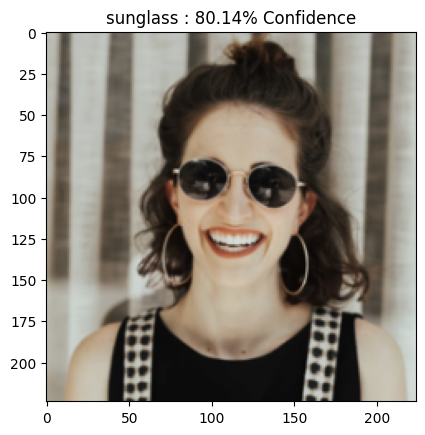

In [ ]:
def get_imagenet_label(probs):
    return decode_predictions(probs, top=1)[0][0]

image_probs = pretrained_model.predict(image)

# Rescale from [-1, 1] to [0, 1] for visualization
plt.figure()
plt.imshow((image[0] + 1.0) / 2.0)
_, image_class, class_confidence = get_imagenet_label(image_probs)
plt.title(f"{image_class} : {class_confidence*100:.2f}% Confidence")
plt.show()

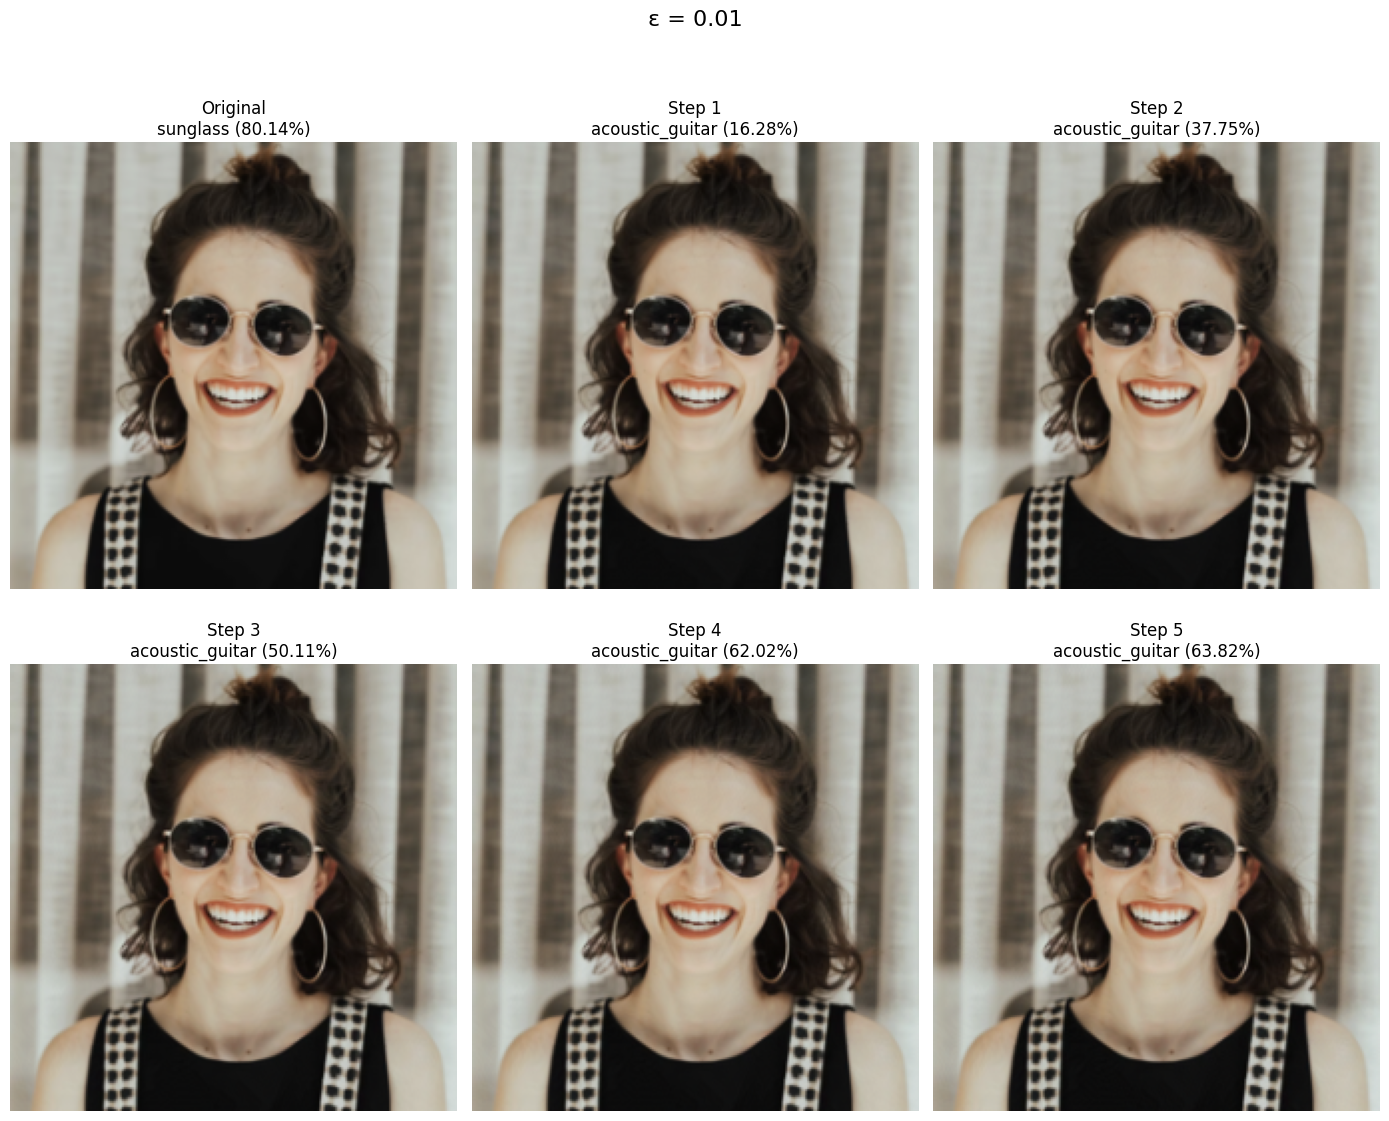

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt

loss_object = tf.keras.losses.CategoricalCrossentropy()

def get_top_prediction(model, img_tensor):
    preds = model(img_tensor, training=False)
    decoded = tf.keras.applications.mobilenet_v2.decode_predictions(preds.numpy(), top=1)[0][0]
    class_name = decoded[1]
    confidence = decoded[2]
    return class_name, confidence

def to_display(img_tensor):
    # Convert MobileNetV2 preprocessed image from [-1, 1] back to [0, 1]
    img = (img_tensor[0] + 1.0) / 2.0
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img.numpy()

def i_fgsm_attack(model, image, label, epsilon, num_iter):
    alpha = epsilon / num_iter
    adv_image = tf.identity(image)
    original_image = tf.identity(image)

    adv_images_per_step = []

    for i in range(num_iter):
        with tf.GradientTape() as tape:
            tape.watch(adv_image)
            prediction = model(adv_image, training=False)
            loss = loss_object(label, prediction)

        gradient = tape.gradient(loss, adv_image)
        signed_grad = tf.sign(gradient)

        adv_image = adv_image + alpha * signed_grad

        # Keep within epsilon-ball around original image
        adv_image = tf.clip_by_value(
            adv_image,
            original_image - epsilon,
            original_image + epsilon
        )

        # Keep within valid MobileNetV2 input range
        adv_image = tf.clip_by_value(adv_image, -1.0, 1.0)

        adv_images_per_step.append(tf.identity(adv_image))

    return adv_image, adv_images_per_step

preds = pretrained_model(image, training=False)
top_idx = tf.argmax(preds[0])
label = tf.one_hot(top_idx, depth=1000)
label = tf.reshape(label, (1, 1000))

# --- Run attack ---
num_iter = 5
epsilon = 0.01 #0.01

adv_image, adv_steps = i_fgsm_attack(
    model=pretrained_model,
    image=image,
    label=label,
    epsilon=epsilon,
    num_iter=num_iter
)

# --- Plot original + each step in grid ---
fig, axes = plt.subplots(2, 3, figsize=(14, 12))
axes = axes.flatten()

fig.suptitle(f"ε = {epsilon}", fontsize=16)

# Original
orig_class, orig_conf = get_top_prediction(pretrained_model, image)
axes[0].imshow(to_display(image))
axes[0].set_title(f"Original\n{orig_class} ({orig_conf:.2%})")
axes[0].axis("off")

# Adversarial steps
for i, adv_img_step in enumerate(adv_steps):
    step_class, step_conf = get_top_prediction(pretrained_model, adv_img_step)
    axes[i + 1].imshow(to_display(adv_img_step))
    axes[i + 1].set_title(f"Step {i+1}\n{step_class} ({step_conf:.2%})")
    axes[i + 1].axis("off")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [ ]:
perturbation = adv_image - image

print("L_inf:", tf.reduce_max(tf.abs(perturbation)).numpy())
print("Mean abs diff:", tf.reduce_mean(tf.abs(perturbation)).numpy())
print("Max allowed epsilon:", epsilon)

L_inf: 0.010000005
Mean abs diff: 0.0051566255
Max allowed epsilon: 0.01
